In [16]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv

from scipy import stats as ss
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
import mc3

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/sim_series/'
N_files = 20  # 20 temporal series (from 0 to 19), need to check file N°20
data_original = []
data_rv = []
for i in range(N_files):
    data_original.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
    data_rv.append(readsav(path_data + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{i}.sav'))
data_original = np.array(data_original)
data_rv = np.array(data_rv)
# wavelength and time arrays
wl_original = np.array(data_rv[0]['lambd'])  # same wavelength grid for all time series (verified)
times = np.arange(0, len(data_original[0]) * 144, 144) / 60 / 24  # time in days, same for all time series
times_sec = times * 86400

## Noisy spectra

In [3]:
# multiply absorption lines and add noise to data_spectra
n_lines = 60
snr = 400
sigma = 1 / snr
data_noisy = []
for ts in data_original:
    ts_noisy = []
    for spec in ts:
        spec = list(spec) * n_lines
        ts_noisy.append(spec + np.random.normal(0, sigma, len(spec)))
    data_noisy.append(ts_noisy)

In [4]:
wl_step = wl_original[1] - wl_original[0]
new_size = len(wl_original) * n_lines

wl = np.arange(wl_original[0], wl_original[0] + new_size * wl_step, wl_step)

In [5]:
# redefine data_spectra to simplify the rest of the code
data_spectra = np.array(data_noisy)

In [6]:
# calculate radial velocity by template matching
mean_spec = np.array([np.mean(i, axis=0) for i in data_spectra])  # list of N_files mean spectra
d_S0 = np.array([np.gradient(i, wl) for i in mean_spec])  # derivative of the mean spectra
C_0 = 1000
rv_tm = []
for j in range(N_files):  # iterate over each time series
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec[j], data_spectra[j][k], C_0))
    rv_tm.append(np.array(rv_j))
rv_tm = np.array(rv_tm)

data_spectra[ i ]: matrix with 3686 spectra of 122 * n_lines elements each \
data_rv[ i ]: dictionary

In [ ]:
S_f = []  # array of spectra matrices
v_vectors = []  # array of velocity vectors

for i in range(N_files):
    # take out projection over the velocity vector
    s, v = t.subtract_v(wl, data_spectra[i], c=3e18)  # speed of light in angstrom/s
    S_f.append(s)
    v_vectors.append(v)

S_f = np.array(S_f)
v_vectors = np.array(v_vectors)

: 

## Apply PCA

In [ ]:
# apply double centering to each spectra matrix
spectra_centered = np.array([t.double_centering(i) for i in S_f])

In [ ]:
# apply PCA to the centered spectra matrix
n_components = 20

pcs_ts = []  # list of N_files lists of of principal components
loadings_ts = []
scores_ts = []

for i in spectra_centered:  # each is is a double-centered matrix
    pca_flux_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_flux_i.fit_transform(i)            # fit the model with spectra_centered and apply the dimensionality reduction
    pcs_ts.append(pcs_i)
    loadings_ts.append(pca_flux_i.components_)
    scores_ts.append(np.array([pcs_i[:, j] for j in range(n_components)]))

pcs_ts = np.array(pcs_ts)
loadings_ts = np.array(loadings_ts)
scores_ts = np.array(scores_ts)

In [ ]:
# calculate power spectrum
dt = times[1] - times[0]
file = 8  # pick one file to show components
pcs = pcs_ts[file]
scores = scores_ts[file]
loadings = loadings_ts[file]

# power spectrum
pgs = np.array([t.calculate_periodogram(times_sec, scores[i]) for i in range(n_components)])  # calculate periodograms
ft, ps, freq = pgs[:, 0], pgs[:, 1], pgs[:, 2]  # save FT, PS and frequencies

# correlation coefficient between RV and PC1
corr_1 = np.array([ss.pearsonr(scores_ts[i][0], rv_tm[i])[0] for i in range(N_files)])

In [ ]:
# save data
min_r = min(corr_1)
max_r = max(corr_1)
mean_r = np.mean(corr_1)
std_r = np.std(corr_1)
median_r = np.median(corr_1)
p16 = np.percentile(corr_1, 16)
p84 = np.percentile(corr_1, 84)
stats = [snr, min_r, max_r, mean_r, std_r, median_r, p16, p84, True, n_lines]

with open('../data/snr_corr.csv', 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(stats)

## SNR vs number of lines

In [9]:
data_r = pd.read_csv('../data/snr_corr.csv')
df = data_r[data_r['noisy_rv'] == True]  # noisy rv
data_r.head()

,snr,min_r,max_r,mean_r,std_r,median_r,p16_r,p84_r,noisy_rv,n_lines
0,1000,0.107,0.537,0.295,0.1110,0.286,0.197,0.400,True,1.0
1,1100,0.116,0.570,0.438,0.1040,0.454,0.357,0.528,True,1.0
2,1200,0.351,0.700,0.554,0.0935,0.563,0.438,0.640,True,1.0
3,1300,0.468,0.701,0.603,0.0677,0.618,0.539,0.665,True,1.0
4,1400,0.539,0.784,0.704,0.0496,0.714,0.680,0.731,True,1.0


In [10]:
lines = sorted(list(set(data_r['n_lines'].to_numpy())))
df_n = {}
for n in lines:
    df_n[n] = df[df['n_lines'] == n]

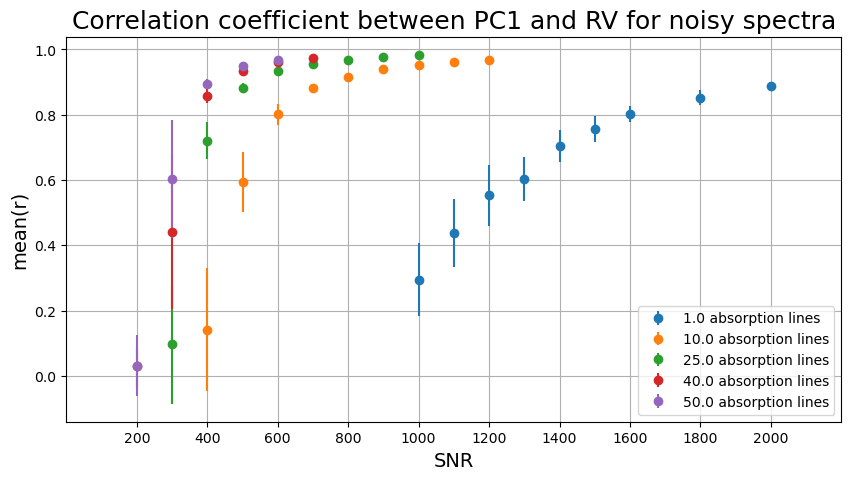

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for n in lines:
    snr_n = df_n[n]['snr'].to_numpy()
    mean_n = df_n[n]['mean_r'].to_numpy()
    std_n = df_n[n]['std_r'].to_numpy()
    ax.errorbar(snr_n, mean_n, yerr=std_n, fmt='o', label=f'{n} absorption lines', zorder=3)

ax.set_title('Correlation coefficient between PC1 and RV for noisy spectra', size=18)
ax.set_xlabel('SNR', size=14)
ax.set_ylabel('mean(r)', size=14)
ax.set_xticks(np.arange(200, 2200, 200))
ax.set_xlim(0, 2200)
ax.grid()
#ax.xaxis.set_inverted(True)
ax.legend(loc='lower right')

plt.show()

In [ ]:
# calculate the improvement factor
for n in lines:
    snr_n = df_n[n]['snr'].to_numpy()
    mean_n = df_n[n]['mean_r'].to_numpy()
    std_n = df_n[n]['std_r'].to_numpy()

3.5

In [15]:
snr_25 = df_n[25]['snr'].to_numpy()
r_25 = df_n[25]['mean_r'].to_numpy()

In [27]:
# testing mc3 fit on a quadratic function
# quadratic function
def exp(params, x):
    a, b, c = params
    return a * b**x + c

# generate data
snr = .1
sigma = 1 / snr
x = snr_25
p = [1, 10, 0]  # parameters
data = exp(p, x) + np.random.normal(0, sigma, len(x))

# fit
p0 = p

out = mc3.sample(
    data=data,
    uncert=np.ones_like(data),  # or your actual uncertainties
    func=exp,
    params=p0,  # initial parameters
    indparams=[x],
    sampler='snooker',
    nsamples=5000,
    burnin=1000,
    nchains=4,
    savefile=None,
)

bestp = out['bestp']  # best-fit parameters
stdp = out['stdp']  # error for each parameter
posterior = out['posterior']  # MCMC samples


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
  Multi-core Markov-chain Monte Carlo (mc3).
  Version 3.2.1.
  Copyright (c) 2015-2026 Patricio Cubillos and collaborators.
  mc3 is open-source software under the MIT license (see LICENSE).
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

Yippee Ki Yay Monte Carlo!
Start MCMC chains  (Mon Jun 15 15:00:41 2026)

[:         ]  10.1% completed  (Mon Jun 15 15:00:41 2026)
Out-of-bound Trials:
[0 0]
Best Parameters: (chisq=664.3843)
[0. 9.]

[::        ]  21.1% completed  (Mon Jun 15 15:00:41 2026)
Out-of-bound Trials:
[0 0]
Best Parameters: (chisq=664.3843)
[0. 9.]

[:::       ]  30.1% completed  (Mon Jun 15 15:00:41 2026)
Out-of-bound Trials:
[0 0]
Best Parameters: (chisq=664.3843)
[0. 9.]

[::::      ]  41.5% completed  (Mon Jun 15 15:00:41 2026)
Out-of-bound Trials:
[0 0]
Best Parameters: (chisq=664.3843)
[0. 9.]

[:::::     ]  50.7% completed  (Mon Jun 15 15:00:41 2026)
Out-of-bound Trials:

In [28]:
bestp

array([-6.62940567e+11, -1.44985349e+12,  0.00000000e+00])

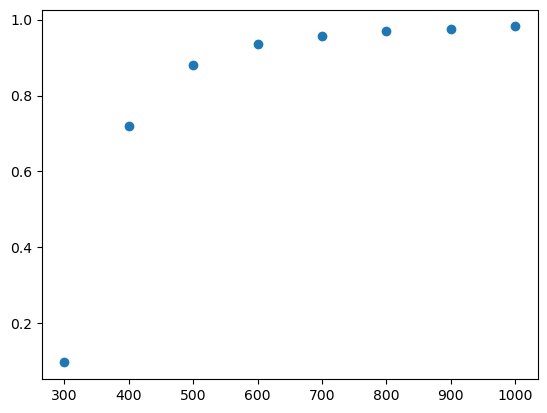

In [32]:
plt.scatter(snr_25, r_25)
plt.plot(snr_25, exp(bestp, snr_25))